Place agri_yield_dataset.csv in your notebook working directory and run:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Load the dataset
df = pd.read_csv("agri_yield_dataset.csv")
# 1. Preview top 5 rows
print("--- First 5 Records ---")
display(df.head(5))

--- First 5 Records ---


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,38,37,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [5]:
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   object 
 1   Crop               1500 non-null   object 
 2   Soil_Type          1500 non-null   object 
 3   Fertilizer         1500 non-null   object 
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 140.8+ KB


In [ ]:
print("--- Summary Statistics ---")
display(df.describe())

--- Summary Statistics ---


,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,74.968000,61.826000,100.374667,174.620667,28.054027,5771.086000,6.781487,2011.996667
std,34.631063,30.092049,51.109814,67.124555,5.493560,12063.581091,0.671793,7.347606
min,10.000000,5.000000,10.000000,50.000000,18.020000,505.000000,5.500000,2000.000000
25%,50.000000,40.000000,62.000000,127.750000,23.932500,1272.750000,6.300000,2006.000000
50%,75.000000,61.000000,101.000000,175.000000,27.955000,2065.500000,6.780000,2012.000000
75%,99.000000,84.000000,135.250000,225.000000,32.240000,2905.250000,7.270000,2019.000000
max,139.000000,119.000000,199.000000,299.000000,37.960000,88401.000000,8.000000,2024.000000


Confirm there are zero missing records and no duplicated entries

In [7]:
# Check for missing values
print("Missing values per column:", df.isnull().sum())

Missing values per column: State                0
Crop                 0
Soil_Type            0
Fertilizer           0
N                    0
P                    0
K                    0
Rainfall_mm          0
Temperature_C        0
Yield_kg_per_acre    0
Soil_pH              0
Year                 0
dtype: int64


In [8]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Duplicate records count: {duplicates_count}")

Duplicate records count: 0


Generate the distribution plot for the target variable and the correlation heatmap for numerical attributes

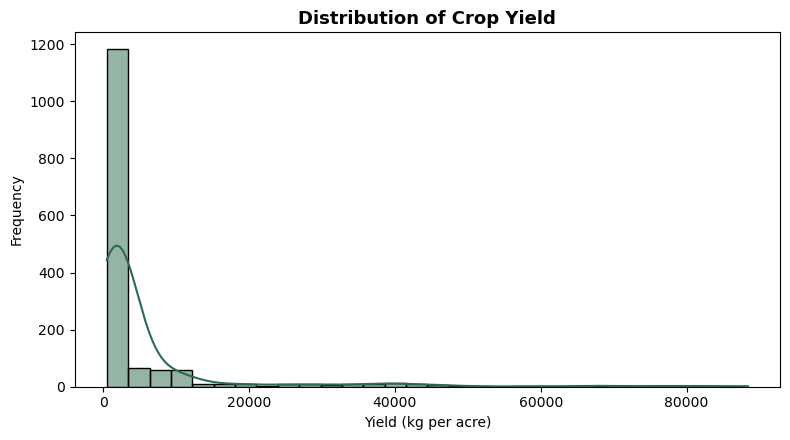

In [ ]:
# Graph 1: Distribution of Crop Yield
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Yield_kg_per_acre'], bins=30, kde=True, color='#2d6a4f')
plt.title("Distribution of Crop Yield", fontsize=13, weight='bold')
plt.xlabel("Yield (kg per acre)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

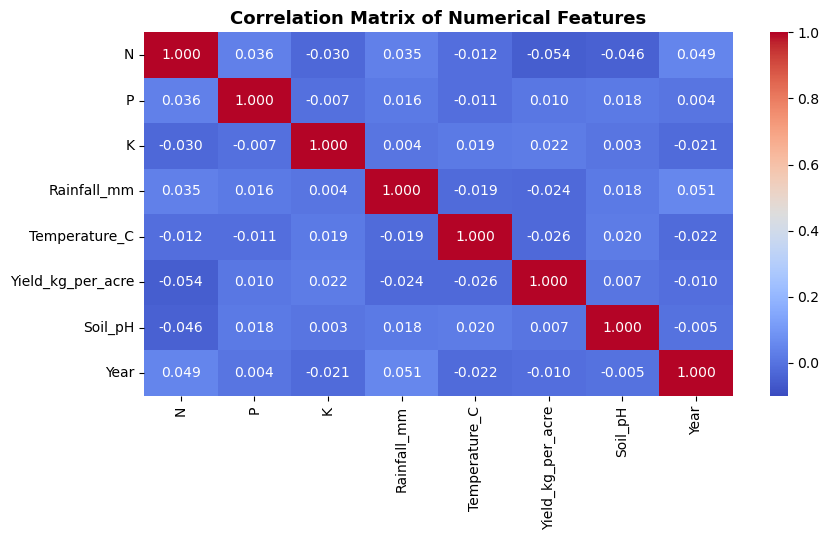

In [ ]:
# Graph 2: Numerical Correlation Heatmap
plt.figure(figsize=(9, 5.5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".3f", cmap='coolwarm', vmin=-0.1, vmax=1.0)
plt.title("Correlation Matrix of Numerical Features", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

Separate target y from features X, apply one-hot encoding to convert text categories, and scale numerical variables using 
StandardScaler

In [ ]:
# Separate features and target
X = df.drop("Yield_kg_per_acre", axis=1)
y = df["Yield_kg_per_acre"]

In [ ]:
# One-Hot Encoding on categorical features (drops first level to avoid collinearity)
X_encoded = pd.get_dummies(X, drop_first=True)
print("Shape after One-Hot Encoding:", X_encoded.shape)


Shape after One-Hot Encoding: (1500, 30)


In [ ]:
# Standardize numerical features
scaler = StandardScaler()
numerical_cols = ['N', 'P', 'K', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Year']
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])
print("Final dataset shape ready for ML training:", X_encoded.shape)
display(X_encoded.head())

Final dataset shape ready for ML training: (1500, 30)


,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Gujarat,State_Haryana,State_Karnataka,...,Crop_Sugarcane,Crop_Wheat,Soil_Type_Black Soil,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_Organic,Fertilizer_Urea
0,0.607519,-0.692307,-0.966373,-0.769285,0.547364,0.057348,-1.224843,False,False,True,...,False,False,False,False,True,False,False,True,False,False
1,-1.327806,-0.858520,0.227534,1.078644,1.077252,-0.553163,-1.360988,False,False,False,...,False,False,False,False,False,True,False,False,False,True
2,-1.067837,-0.825277,1.499729,-0.486134,-0.699967,0.414721,0.408886,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,-0.490128,0.504421,0.560262,0.780591,0.509125,-1.267907,1.361895,True,False,False,...,False,True,False,False,False,True,False,False,False,False
4,0.954144,-0.027458,-0.731506,1.317086,1.776485,-0.806301,0.681175,False,False,False,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [ ]:
# 2. Train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# 3. Model evaluation
y_pred = model.predict(X_test)
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Test R²   : {r2_score(y_test, y_pred):.4f}")

Test RMSE : 13127.18
Test MAE  : 7501.68
Test R²   : -0.1749


In [ ]:
# 4. Predict on a new sample input
sample_raw = pd.DataFrame([{
    'State': 'Punjab',
    'Crop': 'Wheat',
    'Soil_Type': 'Red Soil',
    'Fertilizer': 'Compost',
    'N': 58,
    'P': 77,
    'K': 129,
    'Rainfall_mm': 227,
    'Temperature_C': 30.85,
    'Soil_pH': 5.93,
    'Year': 2022
}])

In [ ]:
# Align dummy variables and scale numerical columns
sample_encoded = pd.get_dummies(sample_raw).reindex(columns=X_encoded.columns, fill_value=0)
sample_encoded[numerical_cols] = scaler.transform(sample_encoded[numerical_cols])

In [ ]:
# Run inference
predicted_yield = model.predict(sample_encoded)[0]
print(f"\n--- Prediction Result ---")
print(f"Predicted Crop Yield: {predicted_yield:.2f} kg/acre")


--- Prediction Result ---
Predicted Crop Yield: 2130.58 kg/acre
